# DBSCAN Clustering
## Isaura Parcel

DBSCAN is applied to mound centroids at three spatial scales: ε = 120 m (mean NND), ε = 200 m (k-distance elbow), and ε = 360 m (3× mean NND). `min_samples = 4` throughout, following Ester et al. (1996).

In [2]:
import numpy as np
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.neighbors import BallTree
from scipy.spatial import ConvexHull
import warnings
warnings.filterwarnings('ignore')

print('imports done')

imports done


## 1. Load data

In [3]:
features = gpd.read_file("/Users/amber/Documents/M Thesis/Data/QGIS/isaura_features.gpkg")
parcel   = gpd.read_file("/Users/amber/Documents/M Thesis/Data/QGIS/08_isaura_extent.shp")
mounds   = features[features['type'] == 'mound'].copy()

print(f"Mound features: {len(mounds)}")
print(f"CRS: {mounds.crs}")

Mound features: 2671
CRS: EPSG:32644


## 2. Extract centroids

In [4]:
centroids = mounds.geometry.centroid
x = centroids.x.values
y = centroids.y.values
coords = np.column_stack([x, y])

print(f"n = {len(coords)}")
print(f"X range: {x.min():.0f} — {x.max():.0f} m")
print(f"Y range: {y.min():.0f} — {y.max():.0f} m")

n = 2671
X range: 364 — 21385 m
Y range: -5 — 15656 m


---
## 3. k-distance plot - epsilon selection

Following Ester et al. (1996): for 2D data, MinPts = 4, so k = 4 for the k-distance plot. The elbow marks the natural transition from dense to sparse - used to select ε.

In [5]:
k = 4  # MinPts = 4 for 2D (Ester et al., 1996)
tree = BallTree(coords, metric='euclidean')
distances, _ = tree.query(coords, k=k + 1)
kth_distances = np.sort(distances[:, k])[::-1]

# Also compute mean NND (k=1) for reference
d2, _ = tree.query(coords, k=2)
mean_nnd = d2[:, 1].mean()

print(f"Mean NND (k=1):     {mean_nnd:.1f} m")
print(f"3x mean NND:        {3*mean_nnd:.0f} m")
print(f"Median {k}-distance: {np.median(kth_distances):.1f} m")

Mean NND (k=1):     120.1 m
3x mean NND:        360 m
Median 4-distance: 213.8 m


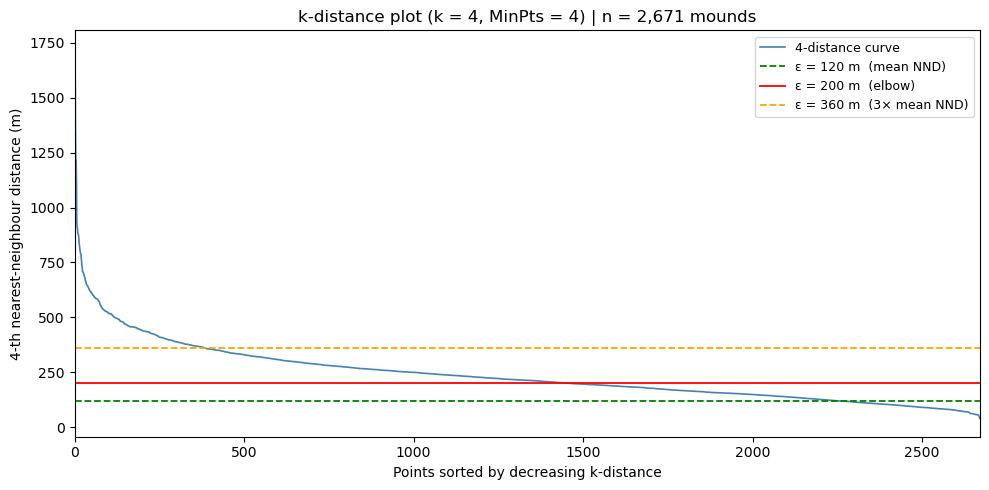

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(kth_distances, color='steelblue', linewidth=1.2, label=f'{k}-distance curve')

for eps_val, label, col, ls in [
    (120, f'ε = 120 m  (mean NND)',   'green',  '--'),
    (200, f'ε = 200 m  (elbow)',      'red',    '-'),
    (360, f'ε = 360 m  (3× mean NND)', 'orange', '--'),
]:
    ax.axhline(eps_val, color=col, linestyle=ls, linewidth=1.3, label=label)

ax.set_xlabel('Points sorted by decreasing k-distance')
ax.set_ylabel(f'{k}-th nearest-neighbour distance (m)')
ax.set_title(f'k-distance plot (k = {k}, MinPts = 4) | n = {len(coords):,} mounds')
ax.set_xlim(0, len(kth_distances))
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('/Users/amber/Documents/M Thesis/Notebooks/dbscan_kdistance.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Run DBSCAN - three spatial scales

Three ε values, `min_samples = 4` throughout.

In [6]:
MIN_SAMPLES = 4
EPS_VALUES  = [120, 200, 360]
EPS_LABELS  = {
    120: 'ε = 120 m  (mean NND)',
    200: 'ε = 200 m  (elbow)',
    360: 'ε = 360 m  (3× mean NND)',
}

results = {}
for eps in EPS_VALUES:
    db     = DBSCAN(eps=eps, min_samples=MIN_SAMPLES, algorithm='ball_tree', metric='euclidean')
    labels = db.fit_predict(coords)
    n_cl   = len(set(labels)) - (1 if -1 in labels else 0)
    n_no   = (labels == -1).sum()
    results[eps] = labels
    print(f"ε = {eps:>4} m | clusters: {n_cl:>4} | noise: {n_no:>5} ({100*n_no/len(labels):.1f}%)")

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
ε =  120 m | clusters:   74 | noise:  1800 (67.4%)
ε =  200 m | clusters:   97 | noise:   749 (28.0%)
ε =  360 m | clusters:   23 | noise:   118 (4.4%)


---
## 5. Cluster maps - individual

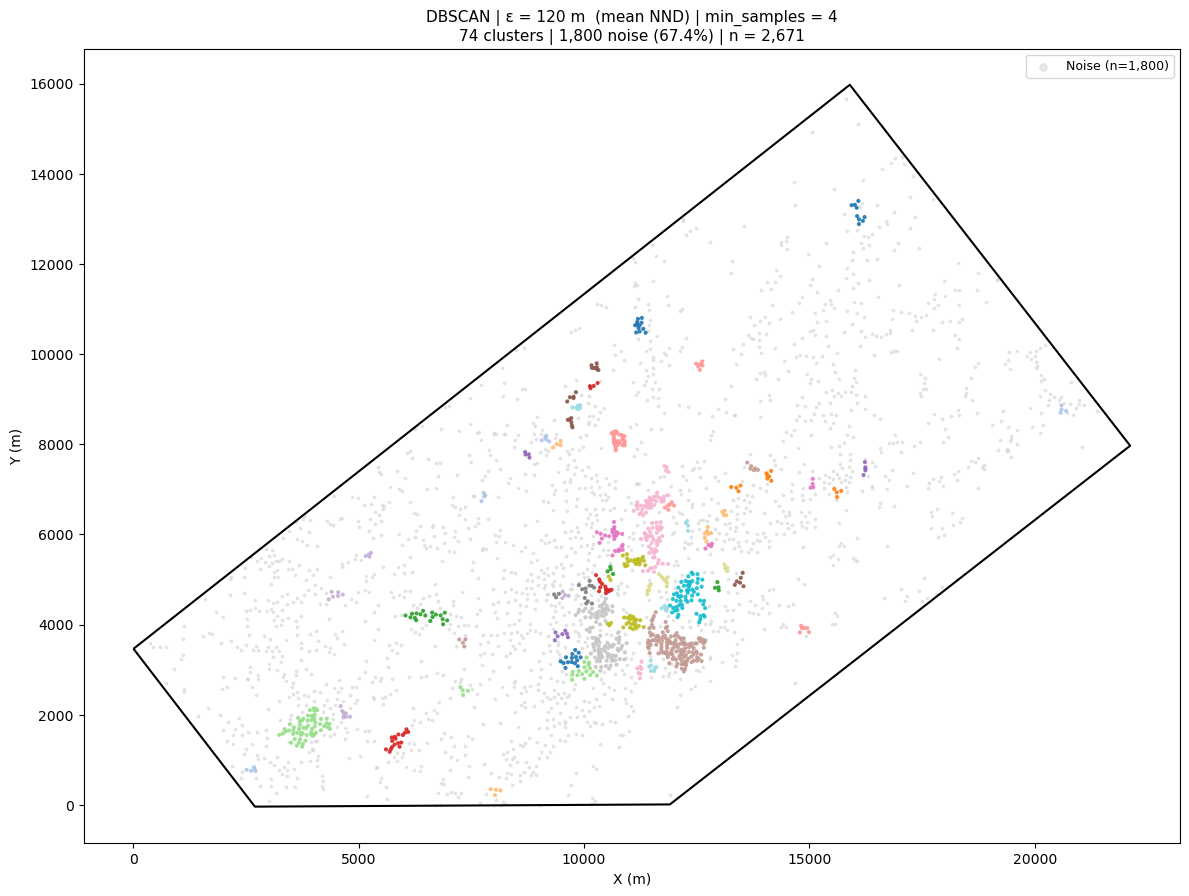

Saved: dbscan_clustermap_120m.png


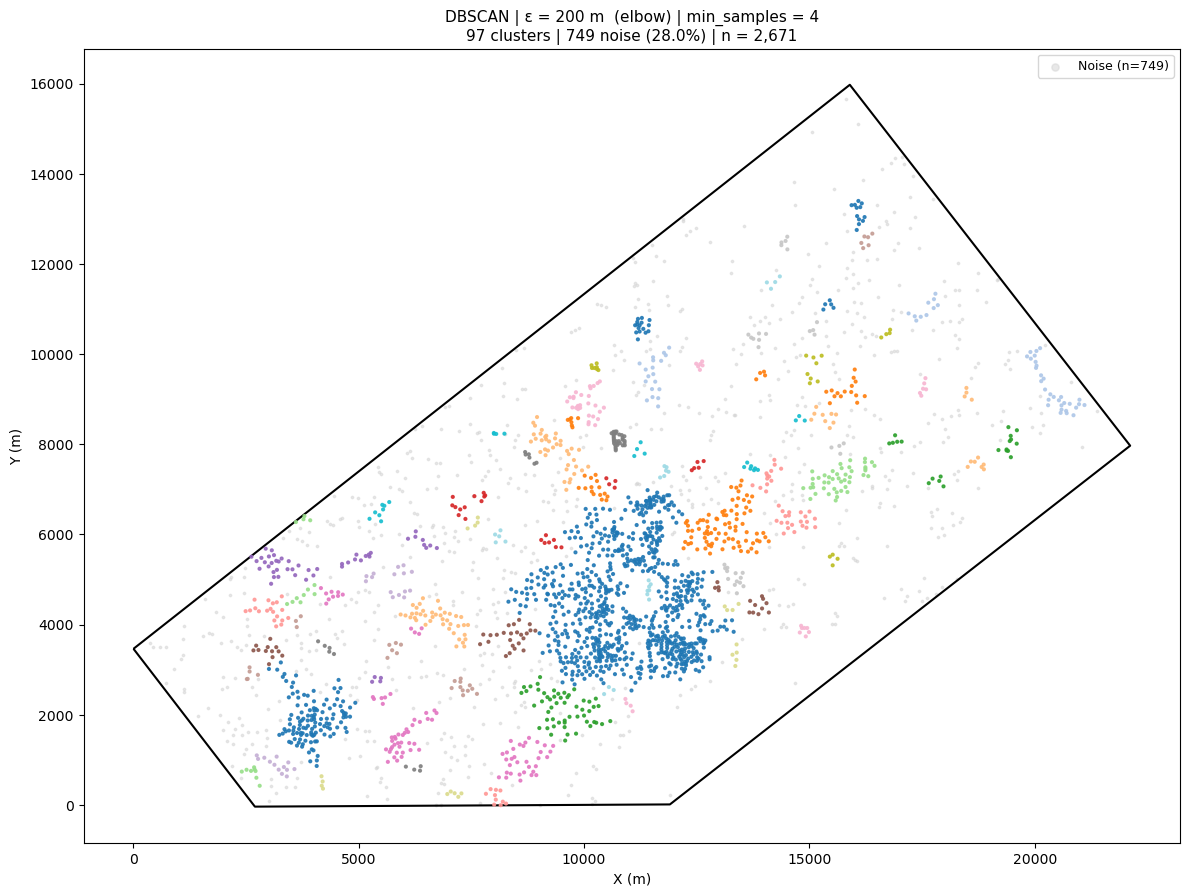

Saved: dbscan_clustermap_200m.png


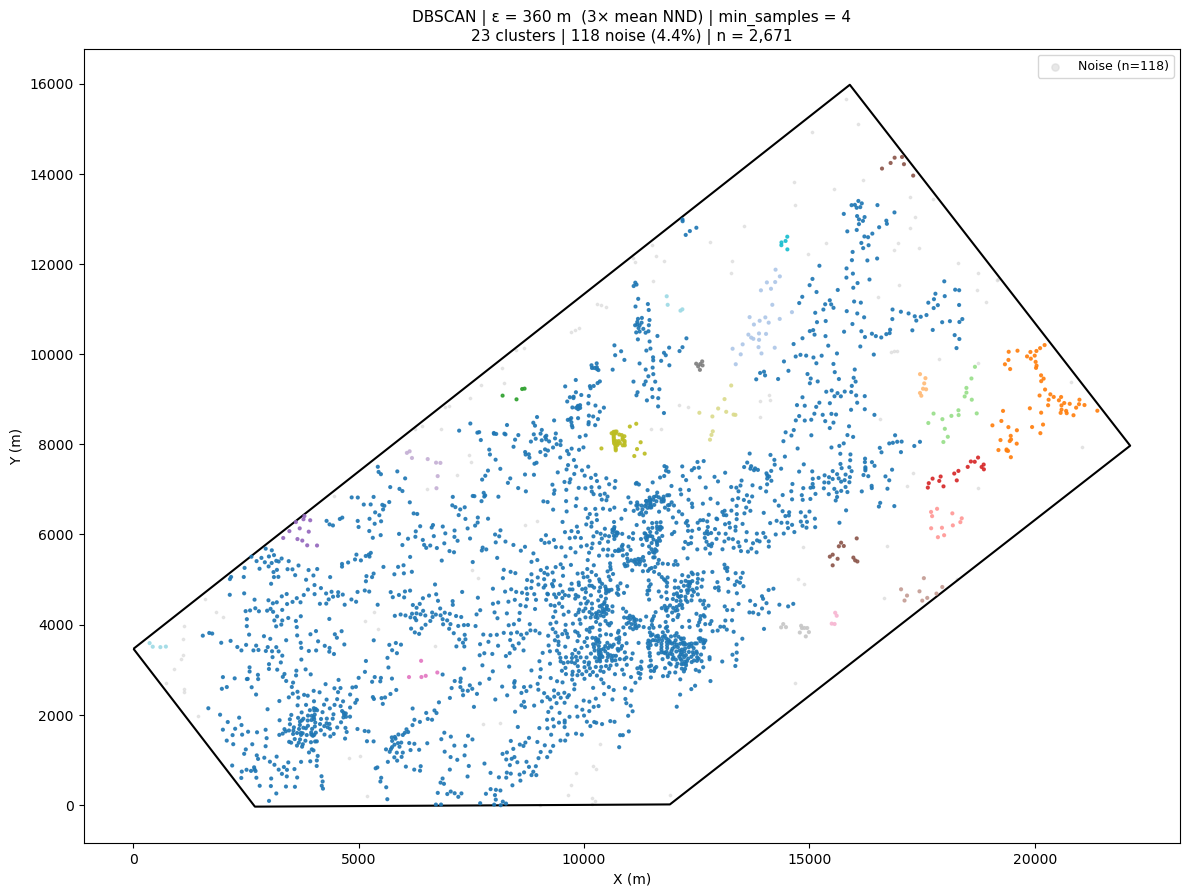

Saved: dbscan_clustermap_360m.png


In [7]:
for eps in EPS_VALUES:
    labels     = results[eps]
    n_cl       = len(set(labels)) - (1 if -1 in labels else 0)
    n_no       = (labels == -1).sum()
    noise_mask = labels == -1
    cl_mask    = ~noise_mask

    fig, ax = plt.subplots(figsize=(12, 10))
    ax.scatter(x[noise_mask], y[noise_mask], s=3, c='lightgrey', alpha=0.5,
               label=f'Noise (n={n_no:,})', zorder=2)
    if cl_mask.sum() > 0:
        ax.scatter(x[cl_mask], y[cl_mask], s=4, c=labels[cl_mask],
                   cmap='tab20', alpha=0.85, zorder=3)
    parcel.boundary.plot(ax=ax, color='black', linewidth=1.5)
    ax.set_title(
        f'DBSCAN | {EPS_LABELS[eps]} | min_samples = {MIN_SAMPLES}\n'
        f'{n_cl} clusters | {n_no:,} noise ({100*n_no/len(labels):.1f}%) | n = {len(labels):,}',
        fontsize=11
    )
    ax.set_xlabel('X (m)')
    ax.set_ylabel('Y (m)')
    ax.set_aspect('equal')
    ax.legend(loc='upper right', fontsize=9, markerscale=3)
    plt.tight_layout()
    plt.savefig(f'/Users/amber/Documents/M Thesis/Notebooks/dbscan_clustermap_{eps}m.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: dbscan_clustermap_{eps}m.png')

---
## 6. Cluster maps - side-by-side comparison

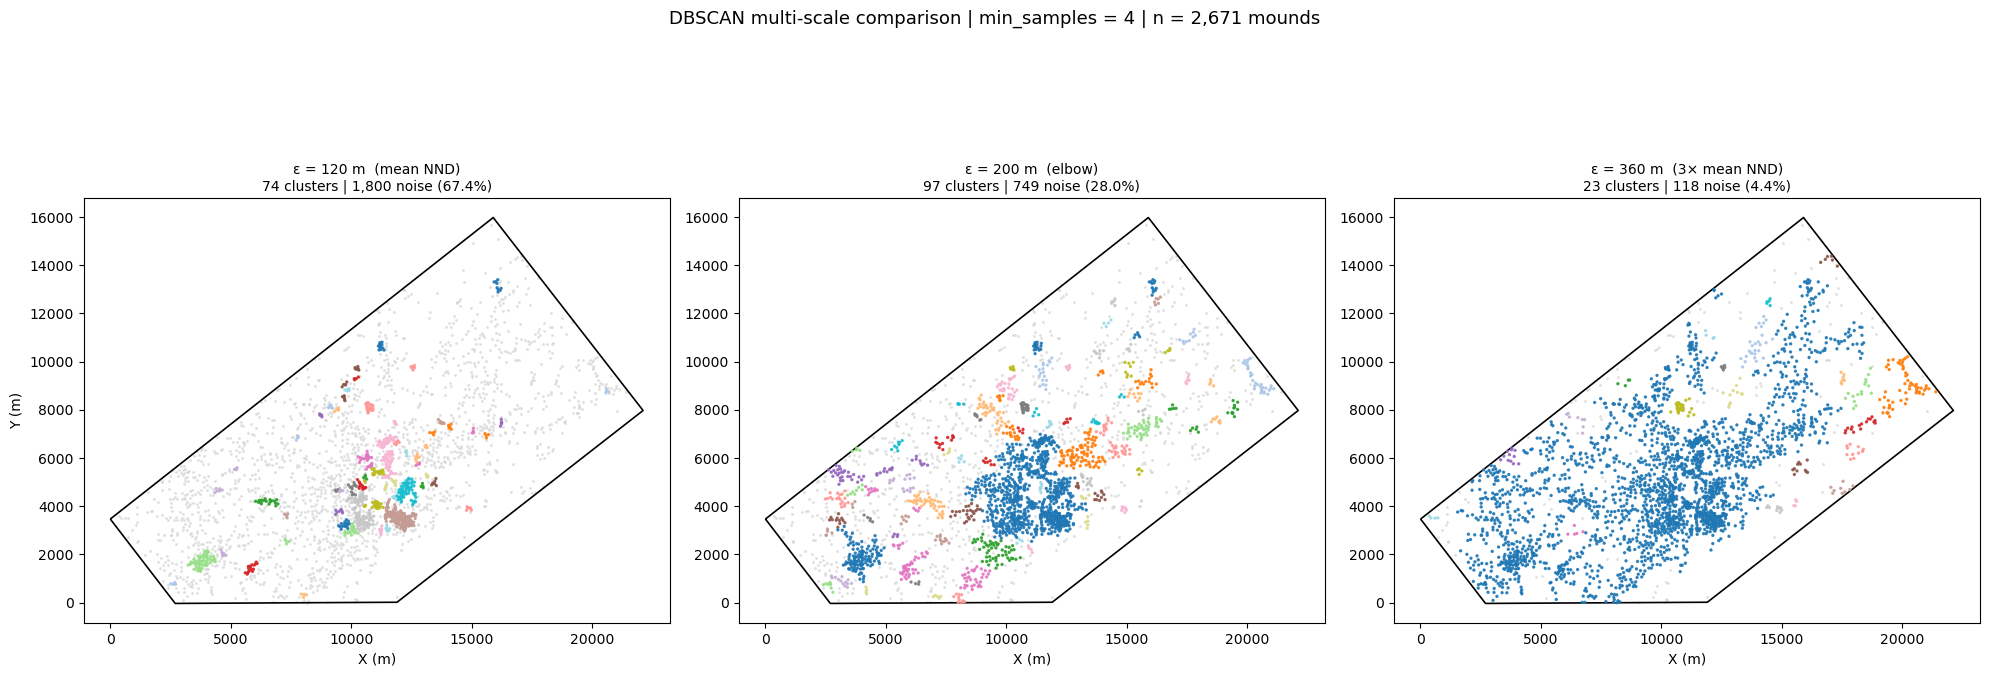

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(20, 8))

for ax, eps in zip(axes, EPS_VALUES):
    labels     = results[eps]
    n_cl       = len(set(labels)) - (1 if -1 in labels else 0)
    n_no       = (labels == -1).sum()
    noise_mask = labels == -1
    cl_mask    = ~noise_mask

    ax.scatter(x[noise_mask], y[noise_mask], s=1.5, c='lightgrey', alpha=0.5, zorder=2)
    if cl_mask.sum() > 0:
        ax.scatter(x[cl_mask], y[cl_mask], s=2, c=labels[cl_mask], cmap='tab20', alpha=0.85, zorder=3)
    parcel.boundary.plot(ax=ax, color='black', linewidth=1.2)
    ax.set_title(f'{EPS_LABELS[eps]}\n{n_cl} clusters | {n_no:,} noise ({100*n_no/len(labels):.1f}%)', fontsize=10)
    ax.set_xlabel('X (m)')
    if ax == axes[0]:
        ax.set_ylabel('Y (m)')
    ax.set_aspect('equal')

fig.suptitle(f'DBSCAN multi-scale comparison | min_samples = {MIN_SAMPLES} | n = {len(coords):,} mounds', fontsize=13)
plt.tight_layout()
plt.savefig('/Users/amber/Documents/M Thesis/Notebooks/dbscan_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Noise analysis

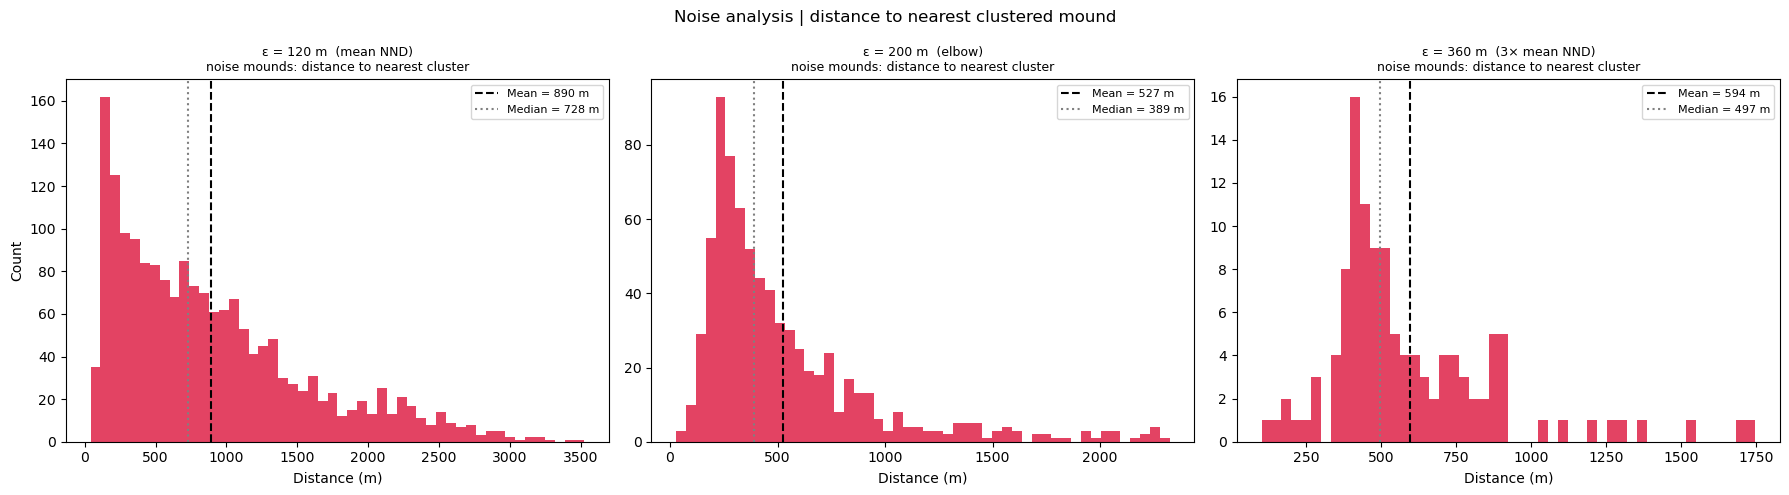

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, eps in zip(axes, EPS_VALUES):
    labels     = results[eps]
    noise_mask = labels == -1
    cl_mask    = ~noise_mask

    if noise_mask.sum() > 0 and cl_mask.sum() > 0:
        tree_cl = BallTree(coords[cl_mask], metric='euclidean')
        dist, _ = tree_cl.query(coords[noise_mask], k=1)
        dist    = dist.ravel()
        ax.hist(dist, bins=50, color='crimson', alpha=0.8, edgecolor='none')
        ax.axvline(dist.mean(),       color='black', linestyle='--', linewidth=1.5, label=f'Mean = {dist.mean():.0f} m')
        ax.axvline(np.median(dist),   color='grey',  linestyle=':',  linewidth=1.5, label=f'Median = {np.median(dist):.0f} m')
        ax.legend(fontsize=8)

    ax.set_title(f'{EPS_LABELS[eps]}\nnoise mounds: distance to nearest cluster', fontsize=9)
    ax.set_xlabel('Distance (m)')
    if ax == axes[0]:
        ax.set_ylabel('Count')

fig.suptitle('Noise analysis | distance to nearest clustered mound', fontsize=12)
plt.tight_layout()
plt.savefig('/Users/amber/Documents/M Thesis/Notebooks/dbscan_noise_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Cluster size distributions

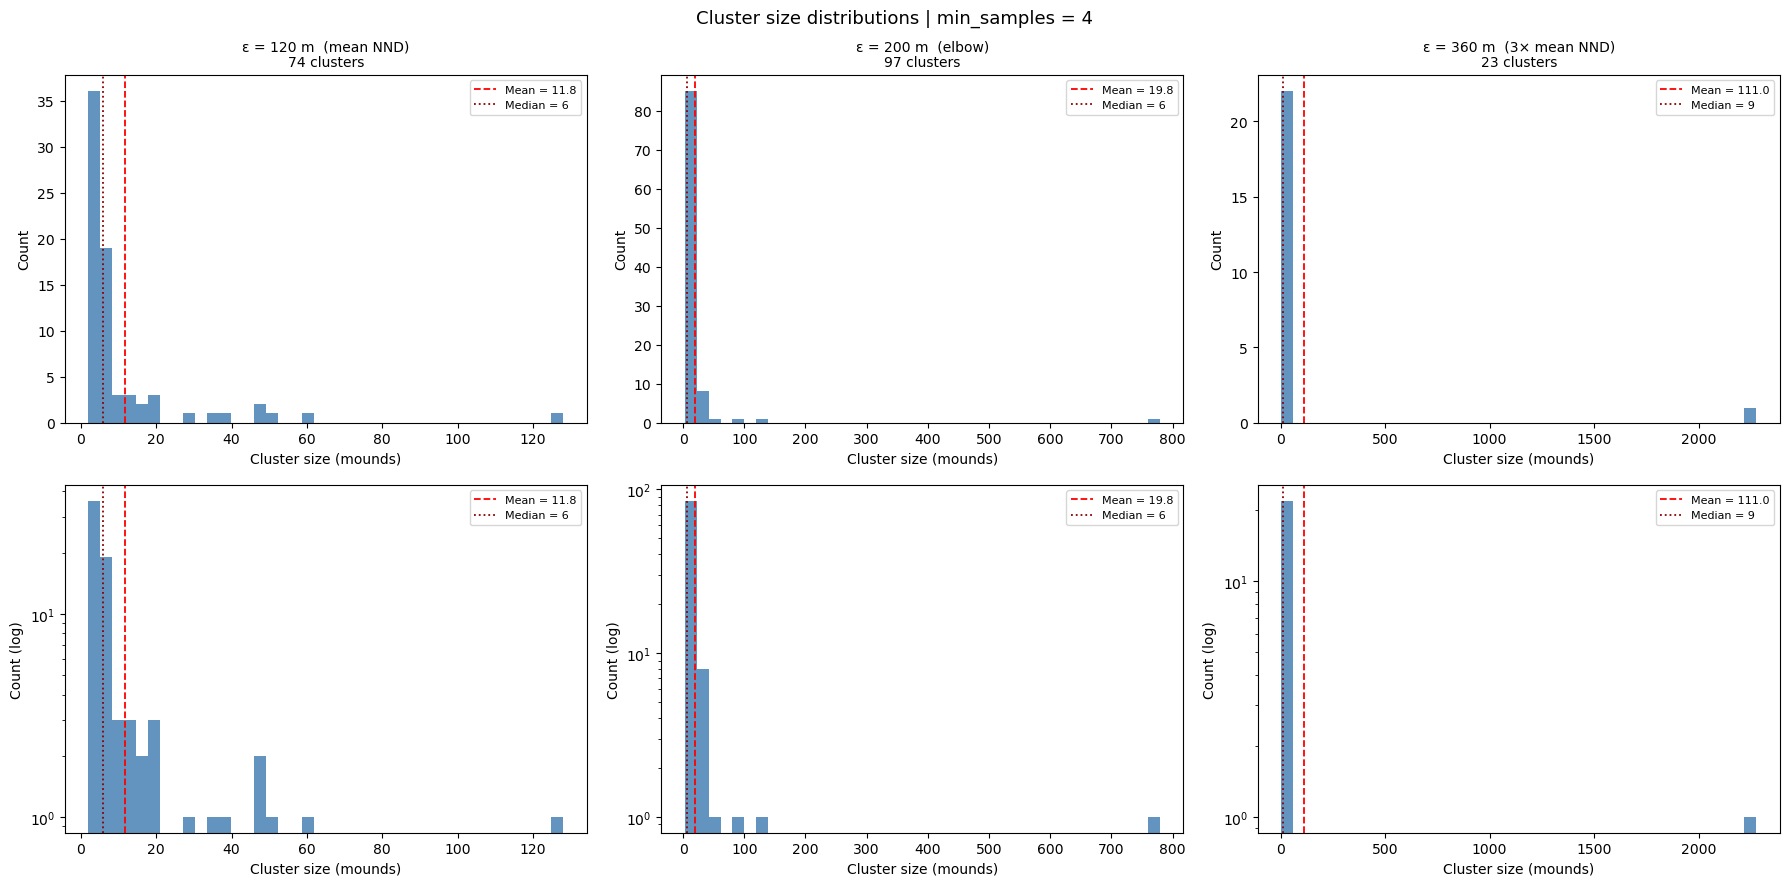

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))

for col, eps in enumerate(EPS_VALUES):
    labels      = results[eps]
    cl_ids      = [c for c in sorted(set(labels)) if c != -1]
    cl_sizes    = np.array([(labels == c).sum() for c in cl_ids])

    for row, (yscale, ylabel) in enumerate([('linear', 'Count'), ('log', 'Count (log)')]):
        ax = axes[row][col]
        ax.hist(cl_sizes, bins=40, color='steelblue', alpha=0.85, edgecolor='none')
        ax.axvline(cl_sizes.mean(),       color='red',    linestyle='--', linewidth=1.3, label=f'Mean = {cl_sizes.mean():.1f}')
        ax.axvline(np.median(cl_sizes),   color='darkred', linestyle=':',  linewidth=1.3, label=f'Median = {np.median(cl_sizes):.0f}')
        ax.set_yscale(yscale)
        ax.set_xlabel('Cluster size (mounds)')
        ax.set_ylabel(ylabel)
        ax.legend(fontsize=8)
        if row == 0:
            ax.set_title(f'{EPS_LABELS[eps]}\n{len(cl_sizes)} clusters', fontsize=10)

fig.suptitle(f'Cluster size distributions | min_samples = {MIN_SAMPLES}', fontsize=13)
plt.tight_layout()
plt.savefig('/Users/amber/Documents/M Thesis/Notebooks/dbscan_cluster_sizes.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 9. Top clusters per scale

The 10 largest clusters at each ε, annotated by rank.

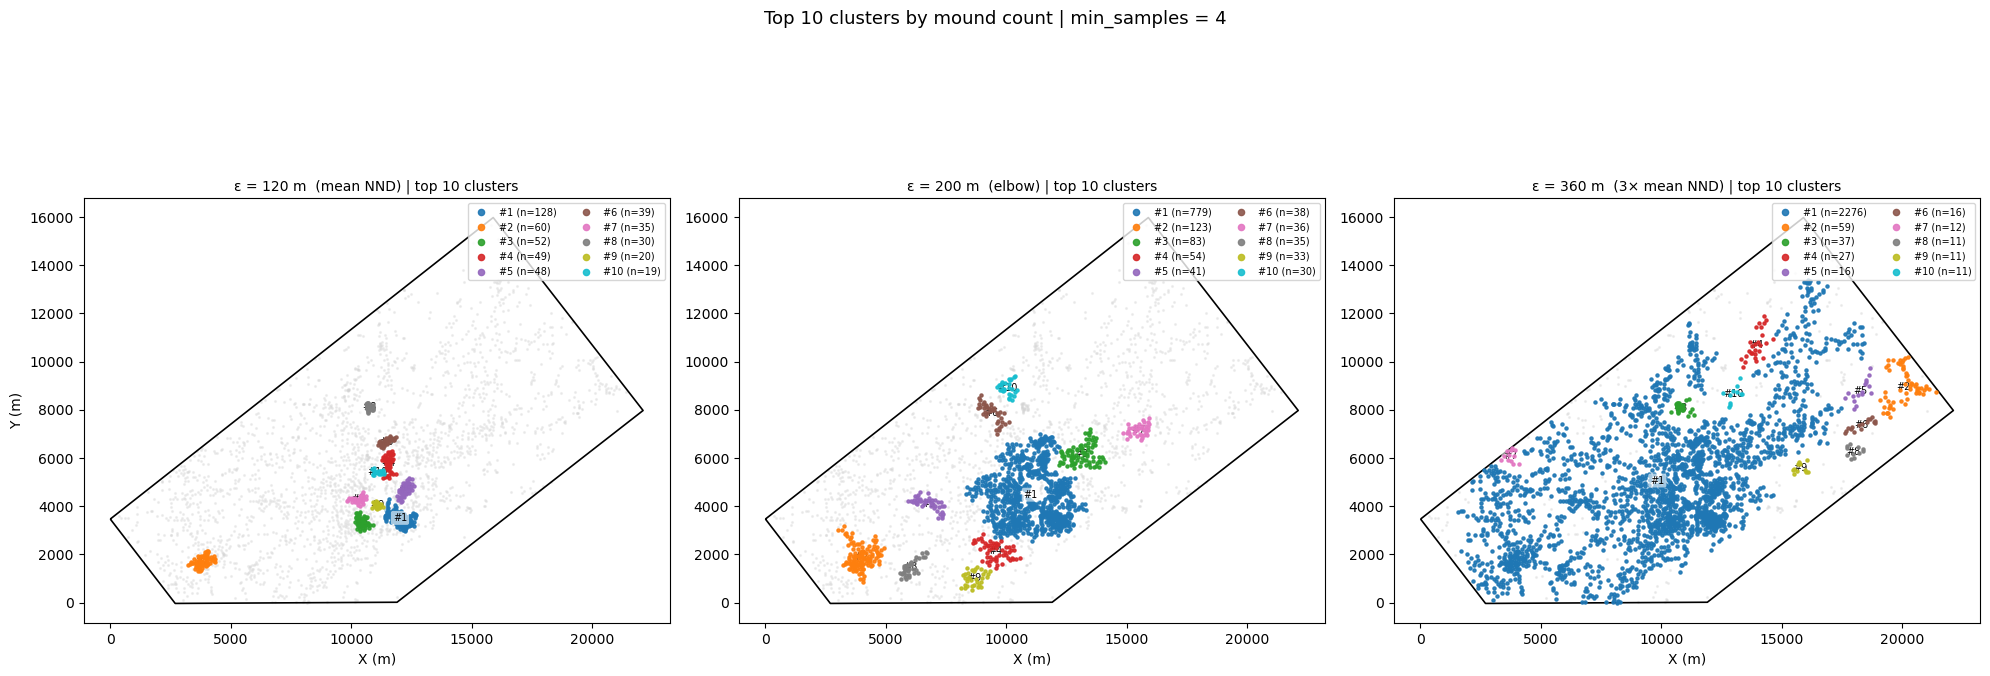

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(20, 8))
cmap_top  = plt.get_cmap('tab10')
top_n     = 10

for ax, eps in zip(axes, EPS_VALUES):
    labels   = results[eps]
    cl_ids   = [c for c in sorted(set(labels)) if c != -1]
    cl_sizes = np.array([(labels == c).sum() for c in cl_ids])
    top_ids  = [cl_ids[i] for i in np.argsort(cl_sizes)[::-1][:top_n]]

    ax.scatter(x, y, s=1.5, c='lightgrey', alpha=0.3, zorder=1)

    for rank, cid in enumerate(top_ids):
        mask_c = labels == cid
        ax.scatter(x[mask_c], y[mask_c], s=5, color=cmap_top(rank / top_n),
                   alpha=0.9, label=f'#{rank+1} (n={mask_c.sum()})', zorder=3 + rank)
        cx, cy = x[mask_c].mean(), y[mask_c].mean()
        ax.annotate(f'#{rank+1}', (cx, cy), fontsize=7, ha='center', va='center',
                    bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.6, ec='none'))

    parcel.boundary.plot(ax=ax, color='black', linewidth=1.2)
    ax.set_title(f'{EPS_LABELS[eps]} | top {top_n} clusters', fontsize=10)
    ax.set_xlabel('X (m)')
    if ax == axes[0]:
        ax.set_ylabel('Y (m)')
    ax.set_aspect('equal')
    ax.legend(loc='upper right', fontsize=7, markerscale=2, ncol=2)

fig.suptitle(f'Top {top_n} clusters by mound count | min_samples = {MIN_SAMPLES}', fontsize=13)
plt.tight_layout()
plt.savefig('/Users/amber/Documents/M Thesis/Notebooks/dbscan_top_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10. Summary statistics

In [12]:
# Per-scale overview
for eps in EPS_VALUES:
    labels   = results[eps]
    cl_ids   = [c for c in sorted(set(labels)) if c != -1]
    cl_sizes = np.array([(labels == c).sum() for c in cl_ids])
    n_no     = (labels == -1).sum()
    n_cl     = len(cl_ids)

    print(f"ε = {eps} m")
    print(f"  clusters:       {n_cl}")
    print(f"  clustered:      {cl_sizes.sum():,} ({100*cl_sizes.sum()/len(labels):.1f}%)")
    print(f"  noise:          {n_no:,} ({100*n_no/len(labels):.1f}%)")
    print(f"  median size:    {np.median(cl_sizes):.0f} mounds")
    print(f"  largest:        {cl_sizes.max()} mounds")
    print()

ε = 120 m
  clusters:       74
  clustered:      871 (32.6%)
  noise:          1,800 (67.4%)
  median size:    6 mounds
  largest:        128 mounds

ε = 200 m
  clusters:       97
  clustered:      1,922 (72.0%)
  noise:          749 (28.0%)
  median size:    6 mounds
  largest:        779 mounds

ε = 360 m
  clusters:       23
  clustered:      2,553 (95.6%)
  noise:          118 (4.4%)
  median size:    9 mounds
  largest:        2276 mounds



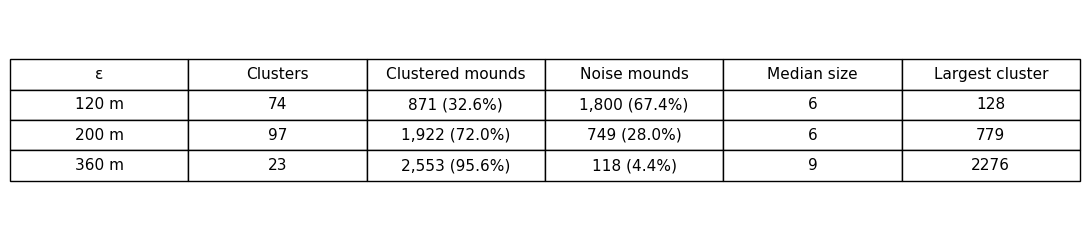

In [13]:
# Summary table — one row per scale
summary_rows = []
for eps in EPS_VALUES:
    labels   = results[eps]
    cl_ids   = [c for c in sorted(set(labels)) if c != -1]
    cl_sizes = np.array([(labels == c).sum() for c in cl_ids])
    n_no     = (labels == -1).sum()
    summary_rows.append([
        f'{eps} m',
        str(len(cl_ids)),
        f'{cl_sizes.sum():,} ({100*cl_sizes.sum()/len(labels):.1f}%)',
        f'{n_no:,} ({100*n_no/len(labels):.1f}%)',
        f'{np.median(cl_sizes):.0f}',
        f'{cl_sizes.max()}',
    ])

fig, ax = plt.subplots(figsize=(11, 2.5))
ax.axis('off')
table = ax.table(
    cellText=summary_rows,
    colLabels=['ε', 'Clusters', 'Clustered mounds', 'Noise mounds', 'Median size', 'Largest cluster'],
    loc='center',
    cellLoc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 1.6)
plt.tight_layout()
plt.savefig('/Users/amber/Documents/M Thesis/Notebooks/dbscan_summary_table.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# Per-cluster detail table — top 20 largest clusters across all scales
detail_rows = []
for eps in EPS_VALUES:
    labels   = results[eps]
    cl_ids   = [c for c in sorted(set(labels)) if c != -1]
    cl_sizes = np.array([(labels == c).sum() for c in cl_ids])
    for cid in [cl_ids[i] for i in np.argsort(cl_sizes)[::-1][:20]]:
        mask_c = labels == cid
        cx_m, cy_m = coords[mask_c, 0], coords[mask_c, 1]
        try:
            hull    = ConvexHull(coords[mask_c])
            area_km = hull.volume / 1e6
            dens    = mask_c.sum() / area_km
        except Exception:
            area_km, dens = np.nan, np.nan
        detail_rows.append({
            'ε (m)': eps,
            'Cluster': cid,
            'Mounds': mask_c.sum(),
            'Centroid X': f'{cx_m.mean():.0f}',
            'Centroid Y': f'{cy_m.mean():.0f}',
            'Hull area (km²)': f'{area_km:.2f}' if not np.isnan(area_km) else '—',
            'Density (mounds/km²)': f'{dens:.1f}' if not np.isnan(dens) else '—',
        })

df_detail = pd.DataFrame(detail_rows)
print(df_detail.to_string(index=False))

 ε (m)  Cluster  Mounds Centroid X Centroid Y Hull area (km²) Density (mounds/km²)
   120       41     128      12027       3513            1.03                124.1
   120       19      60       3847       1722            0.53                112.8
   120       57      52      10435       3366            0.37                141.1
   120       50      49      11548       5791            0.49                 99.6
   120       66      48      12234       4682            0.36                131.6
   120       49      39      11459       6688            0.19                209.8
   120       55      35      10307       4284            0.27                129.7
   120       29      30      10745       8100            0.08                369.8
   120       61      20      11078       4045            0.10                208.6
   120       62      19      11109       5409            0.10                185.6
   120       46      19      10601       6027            0.15                128.5
   1